# __Análise semântica:__
<font size=3>

A **análise semântica** é uma etapa voltada para a **compreensão do significado** por trás das palavras e textos. Ao contrário da **análise sintática**, que foca na estrutura gramatical, a **análise semântica** busca compreender como os termos se relacionam entre si e o contexto geral, permitindo que sistemas computacionais interpretem e gerem linguagem de forma mais próxima da compreensão humana.

Entre as abordagens mais relevantes está a **Análise Semântica Latente**, uma técnica que **reduz a dimensionalidade** dos dados textuais e **revela relações ocultas** entre **termos** e **documentos** com base em seus contextos.  Esse tipo de abordagem é essencial para aplicações como a *recuperação de informações*, *modelagem de tópicos* e *similaridade entre textos e palavras*, onde entender o sentido real das expressões é fundamental para fornecer respostas precisas e relevantes.

## __1. O vetor semântico:__
<font size=3>
    
Agora que entendemos como ponderar a frequência de palavras em textos usando TF-IDF, é hora de avançar para uma camada mais profunda da análise linguística &mdash; **o significado das palavras (semântica)**.  

Embora o TF-IDF seja útil para quantificar a relevância lexical, ele tem uma limitação fundamental: **ignora as relações semânticas entre termos**. Isso significa que duas frases semanticamente equivalentes, mas com palavras diferentes (como sinônimos), gerariam vetores totalmente distintos. Além disso, as representações vetoriais do TF-IDF tendem a ser **esparsas** (com muitos zeros e pouca informação numérica densa), o que limita sua capacidade de capturar nuances de significado.  

<font size=3>

Para solucionarmos esses pontos, precisamos de uma representação mais compacta e rica em significado &mdash; os **vetores semânticos** (ou *vetores de tópicos*). Técnicas como **análise semântica latente** permitem extrair o significado subjacente dos textos, lidando até mesmo com fenômenos complexos como a **polissemia** &mdash; que ocorre quando uma palavra ou frase assume múltiplos significados dependendo do contexto. Alguns exemplos incluem:  

- **Homônimos**: Palavras idênticas em grafia e pronúncia, mas com significados distintos.  
  *Ex.:* "manga" (fruta) vs. "manga" (parte da camisa).  
- **Zeugma**: Figura de linguagem em que uma palavra assume dois sentidos numa mesma frase.  
  *Ex.:* "Ele fechou os olhos e o acordo."  
- **Homógrafos**: Palavras com a mesma escrita, mas pronúncias e significados diferentes.  
  *Ex.:* "colher" (verbo) vs. "colher" (utensílio).  
- **Homófonos**: Palavras com a mesma pronúncia, mas grafias e significados distintos.  
  *Ex.:* "cela" (cadeia) vs. "sela" (equipamento de montaria).  
    

## __2. Análise Semântica Latente:__
<font size=3>

A **análise semântica latente** (*latent semantic analysis* &mdash; LSA) assume que **palavras usadas em contextos semelhantes tendem a ter significados relacionados** (*"me diga com quem andas que eu direi quem tu és"*). Ela captura essas relações analisando padrões de **co-ocorrência de termos** em um _corpus_, _i.e._, *duas ou mais palavras que aparecem juntas no mesmo contexto*, reduzindo a dimensionalidade dos dados para revelar estruturas semânticas subjacentes.
Por exemplo, se um corpus contém os termos "médico", "doutor" e "hospital", LSA pode agrupá-los em um mesmo conceito latente ("saúde"), mesmo que nunca co-ocorram diretamente.

<font size=3>
    
Para desenvolver a LSA, precisamos seguir três passos:
1. Criar a **matriz termo-documento**, em que cada linha representa uma palavra, e cada coluna, um documento (ou parágrafo, ou sentença);

2. Reduzir a dimensionalidade da matriz termo-documento com a **decomposição em valores singulares**, a fim de identificar padrões ocultos e associações semânticas;

3. Mapear o **espaço semântico latente**, no qual as palavras e os documentos são representados em um espaço vetorial de menor dimensão.

### __2.1 A matriz termo-documento:__
<font size=3>

Essa matriz representa a frequência (ou peso) das palavras em cada documento de um _corpus_, podendo ser composta utilizando o dicionário **bag-of-words** ou **TF-IDF**.\
Para ilustrar sua criação, considere os seguintes documentos:

> **Doc1**: "Beautiful is better than ugly",\
  **Doc2**: "Explicit is better than implicit",\
  **Doc3**: "Simple is better than complex"

Após o pré-processamento dos documentos e calcularmos o dicionário TF-IDF por documento ($\texttt{tfidf-docs}$), a **matriz termo-documento** ficará:

| Termo     | Doc1 | Doc2 | Doc3 |  
|-----------|------|------|------|  
| beautiful | 0.45 | 0.0  | 0.0  |  
| is        | 0.11 | 0.11 | 0.11 |  
| better    | 0.15 | 0.15 | 0.15 |  
| than      | 0.15 | 0.15 | 0.15 |  
| ugly      | 0.45 | 0.0  | 0.0  |  
| explicit  | 0.0  | 0.45 | 0.0  |  
| implicit  | 0.0  | 0.45 | 0.0  |  
| simple    | 0.0  | 0.0  | 0.45 |  
| complex   | 0.0  | 0.0  | 0.37 |  

Observe que a matriz termo-documento é **esparsa** e de **alta dimensão** (conforme aumenta o número de documentos), portanto, o próximo passo é extrair uma representação mais compacta.

### __2.2 Decomposição em Valores Singulares:__
<font size=3>

A **decomposição em valores singulares** (*singular value decomposition* &mdash; SVD) é uma técnica de **Álgebra Linear** que fatora uma matriz qualquer em **duas matrizes ortogonais** e **uma diagonal**, revelando **estruturas latentes** (informações *escondidas/codificadas*) nos dados,
$$
    A = U\cdot\Sigma\cdot V^T \, ,
$$
onde:
- $A$ é a matriz original $(m\times n)$ &mdash; a matriz termo-documento, no nosso caso;

- $U$ é uma matriz $(m\times m)$ [ortogonal](https://en.wikipedia.org/wiki/Orthogonal_matrix), cujas colunas são *autovetores* da *matriz covariante* $A\cdot A^T$;

- $\Sigma$ é uma matriz retangular $(m\times n)$ [diagonal](https://en.wikipedia.org/wiki/Orthogonal_matrix), tal que $\Sigma = diag(\sigma_1,\, \sigma_2,\, \dots)$ contém os **valores singulares** $\sigma_i$ de $A$ &mdash; que expressa a variância ("importância") de cada direção associada à $U$ e $V$;

- $V^T$ é a transposta da matriz **ortogonal** $(n\times n)$ $V$, cujas linhas são *autovetores* da *matriz covariante* $A^T\cdot A$.

Podemos pensar que, se $A$ é uma matriz de dados, a SVD permite representá-la como uma combinação de "*componentes*" ($U$) ponderados por sua importância ($\Sigma$) e alinhados com padrões subjacentes ($ V^T $). Em outras palavras, a SVD revela a estrutura intrínseca de $A$, separando-a em componentes ortogonais (eixos de um gráfico de espaço latente) e seus respectivos pesos.

In [1]:
import numpy as np

terms = ['beautiful', 'is', 'better',
         'than', 'ugly', 'explicit',
         'implicit', 'simple', 'complex']

docs = {'Doc1':"Beautiful is better than ugly",
        'Doc2':"Explicit is better than implicit",
        'Doc3':"Simple is better than complex"}

# definindo a matriz termo-documento:
A = np.array([[0.45, 0.0, 0.0],
              [0.11, 0.11, 0.11],
              [0.15, 0.15, 0.15],
              [0.15, 0.15, 0.15],
              [0.45, 0.0, 0.0],
              [0.0, 0.45, 0.0],
              [0.0, 0.45, 0.0],
              [0.0, 0.0, 0.45],
              [0.0, 0.0, 0.37]])

# calculando a SVD:
U, σ, Vt = np.linalg.svd(A)

# S são os valores singulares, que ocupam a diagonal de Σ,
# assim, reconstruiremos Σ abaixo:
Σ = np.zeros_like(A, dtype=float)
Σ[:len(σ), :len(σ)] = np.diag(σ)

print(f"A:{A.shape} = U:{U.shape} · Σ:{Σ.shape} · Vt:{Vt.shape}\n")

print(f"U = {U}\n")
print(f"σ = {σ}")
print(f"Σ = {Σ}\n")
print(f"V^T = {Vt}")

A:(9, 3) = U:(9, 9) · Σ:(9, 3) · Vt:(3, 3)

U = [[-3.81158168e-01 -5.00000000e-01  2.36873745e-01 -1.39045259e-01
  -6.81645486e-01  1.05524818e-01  1.05524818e-01  1.58984891e-01
   1.30720910e-01]
 [-2.51716512e-01  1.40435349e-16 -4.92457236e-02 -2.10570538e-01
  -1.88904954e-02 -6.65177595e-01 -6.65177595e-01  5.23564756e-02
   4.30486578e-02]
 [-3.43249789e-01  2.89908881e-16 -6.71532594e-02 -2.26979900e-01
  -4.02564555e-02  5.78539704e-02  5.78539704e-02 -6.98537214e-01
  -5.74352820e-01]
 [-3.43249789e-01  2.89908881e-16 -6.71532594e-02  9.20710241e-01
  -7.58441549e-02 -8.24698580e-02 -8.24698580e-02 -7.95552647e-02
  -6.54121065e-02]
 [-3.81158168e-01 -5.00000000e-01  2.36873745e-01 -4.07253899e-02
   7.24963366e-01  6.52794452e-02  6.52794452e-02  8.75810189e-02
   7.20110600e-02]
 [-3.81158168e-01  5.00000000e-01  2.36873745e-01 -8.98853244e-02
   2.16589401e-02  5.85402132e-01 -4.14597868e-01  1.23282955e-01
   1.01365985e-01]
 [-3.81158168e-01  5.00000000e-01  2.36873745e

<font size=3>
<br>
    
Os **valores singulares** $\sigma_i$ correspondem às direções **mais importantes** (*variância máxima*) nos dados &mdash; sempre ordenados do maior para o menor. Assim, podemos **selecionar** aqueles valores singulares que apresentam **mais informações**, pois os valores menores muitas vezes representam **ruído** ou **variações menos significativas**.

Ao **truncar** (selecionar) os $k$ maiores valores de $\sigma_i$, preservamos a estrutura essencial dos dados com mínima perda de informação. Em LSA, os valores singulares estão associados aos **eixos semânticos**, o que forma o **espaço latente de conceitos**  &mdash; no qual a informação semântica fica escondida. Assim, os valores singulares $\sigma_{i\leq k}$ capturam os padrões mais fortes de **co-ocorrência de termos**. Por exemplo, em
$$
\Sigma = \begin{bmatrix}
10 & 0 & 0 \\
0 & 3 & 0 \\
0 & 0 & 0.5 \\
\end{bmatrix}
$$

- $\sigma_1 = 10 \rightarrow$ Tópico dominante (_e.g._, "ciência");  
- $\sigma_2 = 3 \rightarrow$ Tópico secundário (_e.g._, "tecnologia");  
- $\sigma_3 = 0.5 \rightarrow$ Ruído ou subtópico pouco relevante (_e.g._, termos ambíguos).

Matematicamente, ao truncarmos as $k$ componentes, ficamos com,
$$
    A \approx A_k = U_k \cdot \Sigma_k \cdot V_k^T \, ,
$$
onde:
- $U_k \rightarrow$ contém só as primeiras $k$ **colunas** de $U$;
- $\Sigma_k \rightarrow$  matriz diagonal $k \times k$ com os maiores valores singulares;
- $V_k^T \rightarrow$  contém só as primeiras $k$ **linhas** de $V^T$.


In [2]:
k = 2

# truncando k componentes:
U_k = U[:, :k]
Σ_k = np.diag(σ[:k])
Vt_k = Vt[:k, :]

print(f"U_k = {U_k}\n")
print(f"Σ_k = {Σ_k}\n")
print(f"V^T_k = {Vt_k}")

U_k = [[-3.81158168e-01 -5.00000000e-01]
 [-2.51716512e-01  1.40435349e-16]
 [-3.43249789e-01  2.89908881e-16]
 [-3.43249789e-01  2.89908881e-16]
 [-3.81158168e-01 -5.00000000e-01]
 [-3.81158168e-01  5.00000000e-01]
 [-3.81158168e-01  5.00000000e-01]
 [-2.67433030e-01  1.54255090e-16]
 [-2.19889380e-01  1.26831963e-16]]

Σ_k = [[0.74783904 0.        ]
 [0.         0.6363961 ]]

V^T_k = [[-6.33433240e-01 -6.33433240e-01 -4.44437466e-01]
 [-7.07106781e-01  7.07106781e-01  6.44675666e-17]]


<font size=3>
<br>

Então vamos refletir: se $A_k$ $(m\times n)$ é a matriz termo-documento e SVD truncado revela $k$ **conceitos latentes**, logo $U_k$ $(m\times k)$ corresponde a uma matriz termo-conceito; $\Sigma_k$ $(k,\, k)$, uma matriz que relaciona conceito-conceito; e $V_k^T$ $(k,\, n)$, conceito-documento; de modo que o produto das três retorne uma representação termo-documento. Em resumo, temos as seguintes **interpretações da análise semântica latente** de cada fatoração:

| Matriz        | O que relaciona                         | Dimensão                | Papel na LSA                                       |
|---------------|-----------------------------------------|-------------------------|----------------------------------------------------|
| $U_k$         | **Termos ↔ Conceitos**                  | termos × conceitos       | Representação semântica dos termos.               |
| $\Sigma_k$    | **Peso dos Conceitos**                  | conceitos × conceitos    | Importância de cada conceito.                     |
| $V_k^T$       | **Conceitos ↔ Documentos**              | conceitos × documentos   | Representação semântica dos documentos.           |

<br>

### __2.3 Mapeando o espaço semântico latente:__
<font size=3>

Com essas matrizes truncadas $(U_k,\, \Sigma_k,\, V_k^T)$, podemos criar duas representações de espaços semânticos, **por palavras** e **por documentos**.

#### __2.3.1 Representação de documentos no espaço semântico latente:__
<font size=3>
    
Ao **projetarmos** os pesos dos conceitos $\Sigma_k$ na relação conceitos-documentos $V_k^T$,
$$
    D_k = \Sigma_k \cdot V_k^T \, ,
$$
obteremos a **representação** $D_k$ dos documentos em $k$ dimensões latentes, onde cada coluna é um documento.

In [3]:
import matplotlib.pyplot as plt

Dₖ:(2, 3) = Σₖ:(2, 2) · Vₖ^T:(2, 3)

Doc1: Beautiful is better than ugly.
Doc2: Explicit is better than implicit.
Doc3: Simple is better than complex.


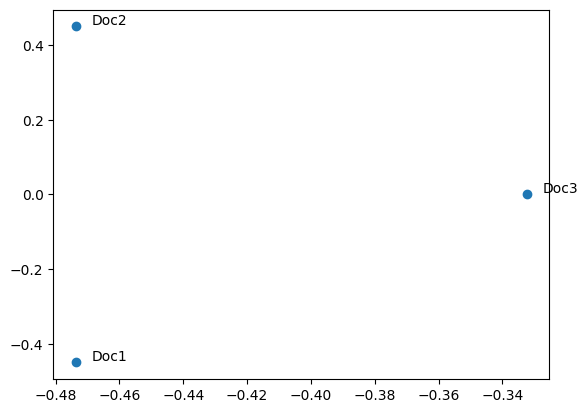

In [4]:
# posição de cada documento no espaço semântico latente:
D_k = Σ_k @ Vt_k

print(f"Dₖ:{D_k.shape} = Σₖ:{Σ_k.shape} · Vₖ^T:{Vt_k.shape}\n")

plt.scatter(D_k[0], D_k[1])

for x, y, s in zip(D_k[0], D_k[1], docs):
    print(f"{s}: {docs[s]}.")
    plt.text(x+0.005, y+0.005, s)

plt.show()

#### __2.3.2 Representação de palavras no espaço semântico latente:__
<font size=3>

Já ao projetarmos a matriz termo-conceito $U_k$ nos pesos dos conceitos $\Sigma_k$, obteremos o que chamamos de **componentes principais** &mdash; eixos do espaço latente de $k$ dimensões. Em LSA, as componentes principais representam os **eixos semânticos**, e o espaço é construído pela matriz termo-conceito $W_k$, dado por
$$
    W_k = U_k \cdot \Sigma_k \,
$$
onde cada linha de $W_k$ é um termo no espaço latente.

Em Álgebra Linear, esse tipo de projeção é realizada na [Análise de Componentes Principais](https://en.wikipedia.org/wiki/Principal_component_analysis) (*principal component analysis* &mdash; PCA), onde $(W_1,\, \dots, W_k)$ são as componentes principais.

Wₖ:(9, 2) = Uₖ:(9, 2) · Σₖ:(2, 2)



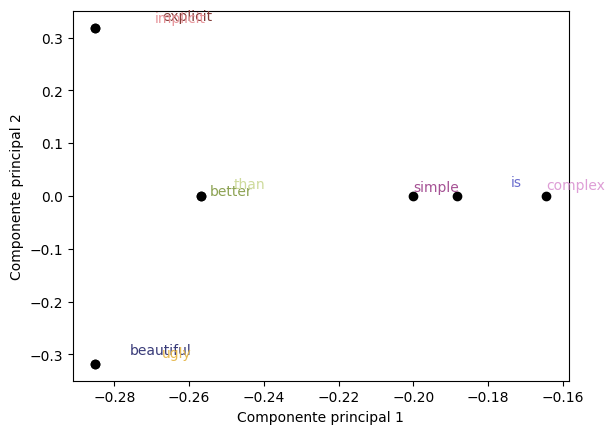

In [5]:
W_k = U_k @ Σ_k

print(f"Wₖ:{W_k.shape} = Uₖ:{U_k.shape} · Σₖ:{Σ_k.shape}\n")

def plot_components(vec):
    colors = plt.cm.tab20b(np.linspace(0, 1, len(vec)))

    plt.scatter(vec[:, 0], vec[:, 1], c='black')

    for i, (x, y, s) in enumerate(zip(vec[:,0], vec[:,1], terms)):
        x0, y0 = 2e-2*np.random.rand(2)

        plt.text(x+x0, y+y0, s, c=colors[i])

    plt.xlabel("Componente principal 1")
    plt.ylabel("Componente principal 2")
    plt.show()

plot_components(W_k)

#### __2.3.3 Utilizando a função $\texttt{TruncatedSVD}$ do $\texttt{sklearn}:$__
<font size=3>

Com a função `TruncatedSVD`, podemos calcular a SVD truncada rapidamente, mas fique atento(a) quanto às diferenças no cálculo quando utilizamos apenas $\texttt{numpy}$.

In [6]:
from sklearn.decomposition import TruncatedSVD

In [7]:
svd = TruncatedSVD(n_components=k)  # definimos o valor de k em uma célula anterior

# a função abaixo retorna a projeção da matriz U_k na matriz Σ_k:
W_k = svd.fit_transform(A) # W_k = U_k · Σ_k (m, n)

# para obtermos as demais matrizes, faremos:
σ_k = svd.singular_values_ # (k, )
Σ_k = np.diag(σ_k)         # (k, k)

Vt_k = svd.components_     # (k, n)

U_k = W_k/σ_k              # (m, k)

print(f"U_k:{U_k.shape}, Σ_k:{Σ_k.shape}, Vt_k:{Vt_k.shape}")

U_k:(9, 2), Σ_k:(2, 2), Vt_k:(2, 3)


<font size=3>
<br>
    
Em tarefas de **classificação de documentos** de **Aprendizado de Máquina**, geralmente utilizamos a transposta do vetor semântico **conceito-documento** $D_k$, *i.e.*, as **amostras** são os **documentos** e os **atributos** são os **conceitos** (vetor latente).

Assim, observe que se utilizamos a **transposta da matriz termo-documento**, teremos que
$$
    A^T_{(doc-term)} \approx (U_k\cdot \Sigma_K\cdot V_k^T)^T = V_k\cdot \Sigma_k^T\cdot U_k^T \, ,
$$
e o vetor semântico **documento-conceito** $D'_k$ (dessa decomposição) fica,
$$
    D'_k = V_k\cdot \Sigma_k^T = (D_k)^T \, ,
$$
O que nos basta implementar, por exemplo:

<font size=2>

>```python
>svd = TruncatedSVD(n_components=50)
>
>D_k = svd.fit_transform(A.T)
>
>```

<br>

#### __2.3.4 Utilizando a função $\texttt{PCA}$ do $\texttt{sklearn}:$__
<font size=3>

Para obtermos as componentes principais $W_k$ utilizando a função `PCA`, o procedimento é o seguinte:
 - Centraliza a distribuição dos dados $A$ na média dos atributos (dos documentos), tal que $\tilde A = A - \left<A\right>$;
 - Calcula a SVD de $\tilde A$ truncando $k$ componentes, para obter $U_k$, $\Sigma_k$ e $V_k^T$;
 - Calcula as componentes principais $W_k = U_k\cdot\Sigma_k$.


In [8]:
from sklearn.decomposition import PCA

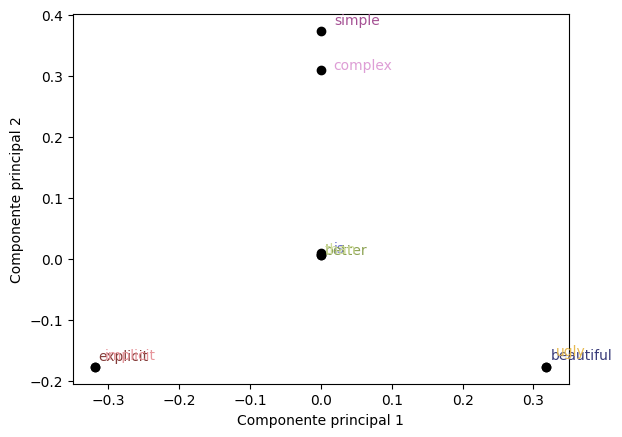

In [9]:
pca = PCA(n_components=k)

pc = pca.fit_transform(A) # principal components

plot_components(pc)

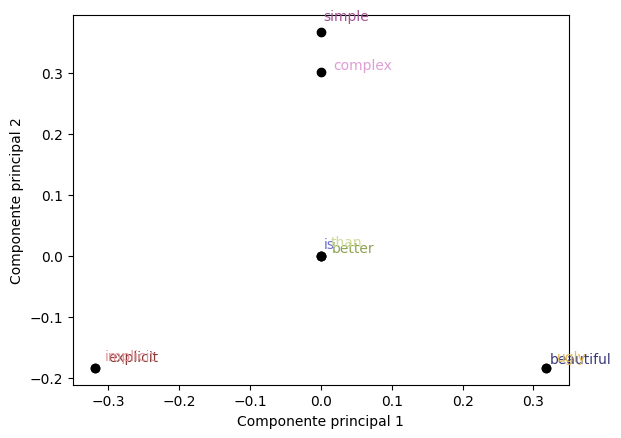

In [10]:
# o que é equivalente fazer:
A_til = A - A.mean(axis=1)[:, np.newaxis]
W_k = svd.fit_transform(A_til)

plot_components(W_k)

## **3. Similaridade entre palavras:**
<font size=3>

Para medir a **similaridade entre palavras** (ou documentos), uma das métricas mais utilizadas é a [similaridade de cosseno](https://en.wikipedia.org/wiki/Cosine_similarity).
Essa medida compara o quão **semelhantes são dois vetores em termos de direção**, ignorando seu comprimento (magnitude).

<font size=3>

Matematicamente, é definida por:

$$
\cos(\theta) = \frac{\vec v_1 \cdot \vec v_2}{\|\vec v_1\|\|\vec v_2\|} \in [-1, +1] \, ,
$$
onde os valores
* **+1** $\rightarrow$ vetores apontam exatamente na mesma direção — **documentos muito semelhantes**.
*  **0** $\;\,\rightarrow$ vetores ortogonais, **sem relação nos padrões** capturados.
* **-1** $\rightarrow$ vetores em direções opostas, indicando **padrões de variação contrários**.

> **Observação:** em representações **originais** como BoW ou TF-IDF, os vetores têm apenas valores positivos, de modo que a similaridade nunca chega a valores negativos.
Entretanto, após **transformações lineares** como **PCA** ou **SVD**, é comum surgirem componentes negativas, o que permite encontrar similaridades negativas (até -1).

Para calcular, podemos utilizar a função [`cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html) do $\texttt{sklearn}$.

In [11]:
from matplotlib.patches import Arc
from sklearn.metrics.pairwise import cosine_similarity

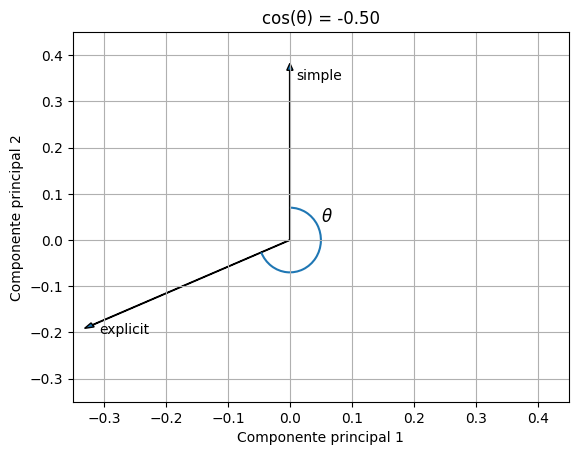

In [12]:
plt.title(f"cos(θ) = {cosine_similarity([W_k[5]], [W_k[7]])[0,0]:.2f}")

θ1 = np.degrees(np.arctan2(W_k[5, 1], W_k[5, 0]))
θ2 = np.degrees(np.arctan2(W_k[7, 1], W_k[7, 0]))

for i in [5, 7]:
    plt.text(W_k[i, 0]+0.01, W_k[i, 1]-0.02, terms[i])
    plt.arrow(0, 0, W_k[i,0], W_k[i, 1], head_width=0.01)

arco = Arc((0, 0), 0.1, 0.14, theta1=θ1, theta2=θ2, color='tab:blue', lw=1.5)

ax = plt.gca()
ax.add_patch(arco)

plt.text(0.05, 0.04, r"$\theta$", fontsize=12)

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.xlim(-0.35, 0.45)
plt.ylim(-0.35, 0.45)
plt.grid()
plt.show()

## __4. Classes no espaço semântico latente:__
<font size=3>

Para exemplificar tudo o que fizemos até este ponto, vamos considerar um [conjunto de dados](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_20newsgroups.html) de notícias de jornal do $\texttt{sklearn}$, a fim de visualizarmos duas categorias de notícias no espaço documento-conceito.

In [13]:
import re
import pandas as pd

import nltk
from nltk.corpus import stopwords

from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import TfidfVectorizer

nltk.download('stopwords')
stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/gilcesarf/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [14]:
# importando o dataset de notícias com duas categorias:
dataset = fetch_20newsgroups(categories=['sci.space', 'talk.politics.misc'])
texts = dataset.data

# pré-processamento dos textos:

def preprocessor(text):

    text = text.lower() # conversão para minúsculo
    text = re.sub(r'http\S+', '', text) # remove links
    text = re.sub(r'\d+', '', text) # remove dígitos em sequência
    text = re.sub(r'[^\w]', ' ', text) # remove pontuações
    text = re.sub(r'\_+', ' ', text) # remove _ em sequência
    text = re.sub(r'\s+', ' ', text) # remove espaços em excesso

    return ' '.join([token for token in text.split() if token not in stop_words])

# obtendo o dataframe termo-documento com TF-IDF:
vectorizer = TfidfVectorizer(preprocessor=preprocessor, min_df=20, max_df=0.95)

tfidf_matrix = vectorizer.fit_transform(texts)

terms = vectorizer.get_feature_names_out()

doc_names = [f'Doc{i+1}' for i in range(len(texts))]

df = pd.DataFrame(tfidf_matrix.T.toarray(), index=terms, columns=doc_names)

df.head()

,Doc1,Doc2,Doc3,Doc4,Doc5,Doc6,Doc7,Doc8,Doc9,Doc10,...,Doc1049,Doc1050,Doc1051,Doc1052,Doc1053,Doc1054,Doc1055,Doc1056,Doc1057,Doc1058
able,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
abortion,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
absolutely,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
ac,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.023465,0.0,0.0,0.0,0.0,0.0,0.0
acad,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


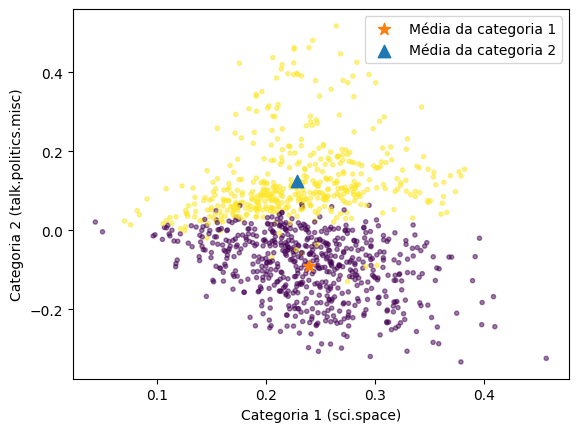

In [15]:
# definindo a matriz termo-documento e o vetor de classes:
A = df.to_numpy()
y = dataset.target

# calculando SVD:
svd = TruncatedSVD(n_components=2)

W_k = svd.fit_transform(A)
Σ_k = np.diag(svd.singular_values_)
Vt_k = svd.components_

D_k = Σ_k @ Vt_k # conceito-documento

y0_mean = D_k[:, y == 0].mean(axis=1)
y1_mean = D_k[:, y == 1].mean(axis=1)

# plotando o espaço latente dos documentos e destacando as classes:
plt.scatter(D_k[0, :], D_k[1, :], marker='.', c=y, alpha=0.5)
plt.scatter(*y0_mean, marker='*', s=80, c="tab:orange", label='Média da categoria 1')
plt.scatter(*y1_mean, marker='^', s=80, c="tab:blue", label='Média da categoria 2')
plt.xlabel("Categoria 1 (sci.space)")
plt.ylabel("Categoria 2 (talk.politics.misc)")
plt.legend()
plt.show()

## __Referências:__
<font size=3>

 - **(4.1-4.5)**: [Natural Language Processing in Action](https://www.manning.com/books/natural-language-processing-in-action);
 - [Principal Component Analysis](https://www.youtube.com/watch?v=Oi4SJqJIL2E&t).
